Imports

In [19]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

Paths

In [20]:
train_imgs = "datasets/WallFeaturesDataset/train/images"
train_labels = "datasets/WallFeaturesDataset/train/labels"

val_imgs = "datasets/WallFeaturesDataset/val/images"
val_labels = "datasets/WallFeaturesDataset/val/images"

test_imgs = "datasets/WallFeaturesDataset/test/images"
test_labels = "datasets/WallFeaturesDataset/test/images"

Checking for Missing Labels

In [21]:
def check_split(img_dir, label_dir, split_name):
    print(f"\nChecking {split_name}...")

    imgs = sorted(os.listdir(img_dir))

    missing_count = 0
    nan_count = 0
    size_mismatch_count = 0

    for img in imgs:
        name = os.path.splitext(img)[0]

        img_path = os.path.join(img_dir, img)
        label_path = os.path.join(label_dir, name + ".png")

        # Missing label
        if not os.path.exists(label_path):
            missing_count += 1
            continue

        # Read image and mask
        image = cv2.imread(img_path)
        mask = cv2.imread(label_path, cv2.IMREAD_UNCHANGED)

        if image is None or mask is None:
            print(f"[READ ERROR] {split_name}/{img}")
            continue

        # Size mismatch
        if image.shape[:2] != mask.shape[:2]:
            print(f"[SIZE MISMATCH] {split_name}/{img}")
            size_mismatch_count += 1

        # NaN check
        if np.isnan(mask).any():
            print(f"[NaN FOUND] {split_name}/{img}")
            nan_count += 1

    print(f"\nSummary for {split_name}")
    print(f"Missing masks  : {missing_count}")
    print(f"NaN masks      : {nan_count}")
    print(f"Size mismatch  : {size_mismatch_count}")


check_split(train_imgs, train_labels, "train")
check_split(val_imgs, val_labels, "val")
check_split(test_imgs, test_labels, "test")

print("\nDone.")


Checking train...

Summary for train
Missing masks  : 0
NaN masks      : 0
Size mismatch  : 0

Checking val...

Summary for val
Missing masks  : 190
NaN masks      : 0
Size mismatch  : 0

Checking test...

Summary for test
Missing masks  : 191
NaN masks      : 0
Size mismatch  : 0

Done.


Plotting distribution of Image Resolutions

Scanning datasets/WallFeaturesDataset/train/images
Scanning datasets/WallFeaturesDataset/val/images
Scanning datasets/WallFeaturesDataset/test/images


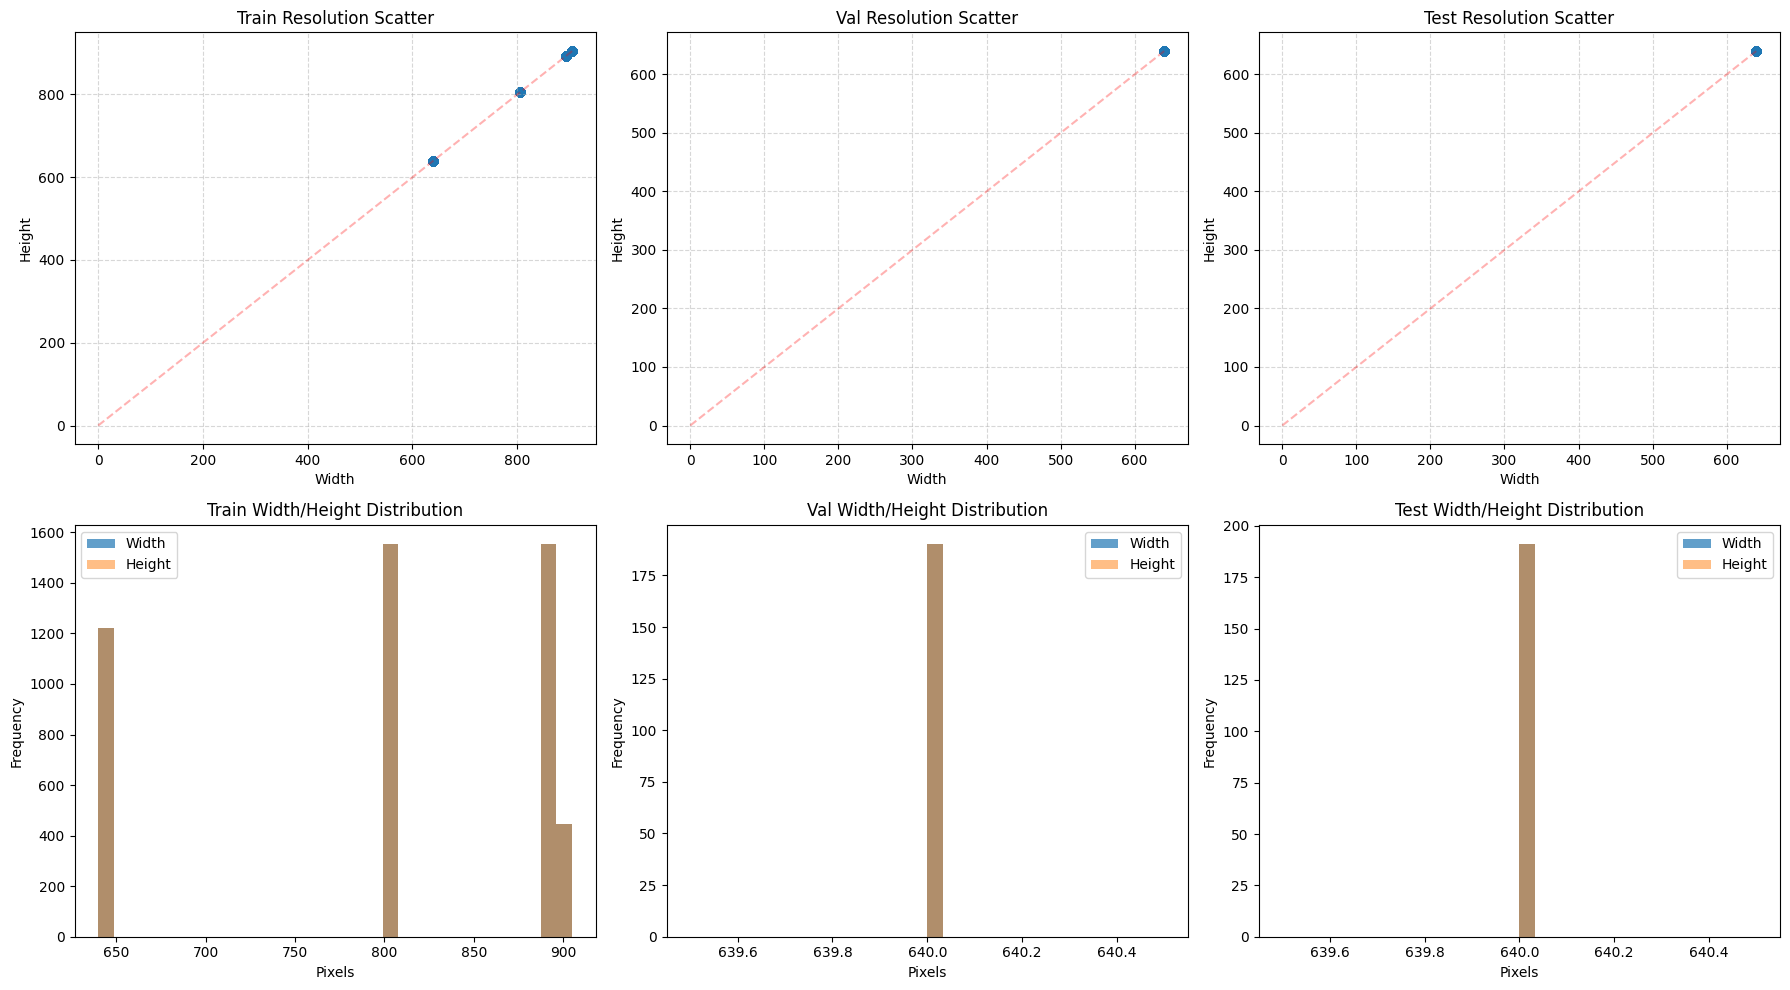

In [22]:
valid_extensions = (".jpg", ".png")


def get_resolutions(folder):
    widths = []
    heights = []

    print(f"Scanning {folder}")

    for file in os.listdir(folder):
        if not file.lower().endswith(valid_extensions):
            continue

        path = os.path.join(folder, file)

        try:
            with Image.open(path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    return widths, heights


train_w, train_h = get_resolutions(train_imgs)
val_w, val_h = get_resolutions(val_imgs)
test_w, test_h = get_resolutions(test_imgs)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

splits = [
    ("Train", train_w, train_h),
    ("Val", val_w, val_h),
    ("Test", test_w, test_h),
]

for i, (name, widths, heights) in enumerate(splits):

    # Scatter plot
    ax = axes[0, i]
    ax.scatter(widths, heights, alpha=0.5)
    ax.set_title(f"{name} Resolution Scatter")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    ax.grid(True, linestyle="--", alpha=0.5)

    if widths and heights:
        max_val = max(max(widths), max(heights))
        ax.plot([0, max_val], [0, max_val], "r--", alpha=0.3)

    # Histogram
    ax = axes[1, i]
    ax.hist(widths, bins=30, alpha=0.7, label="Width")
    ax.hist(heights, bins=30, alpha=0.5, label="Height")
    ax.set_title(f"{name} Width/Height Distribution")
    ax.set_xlabel("Pixels")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

Getting Split between 'Cracks' & 'Joints/Taping-Area'

In [23]:
def count_classes(img_dir, split_name):

    if not os.path.exists(img_dir):
        print(f"Error: The directory '{img_dir}' does not exist.")
        return

    # List all jpg images
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]

    # Counters
    crack_count = 0
    tape_joint_count = 0
    other_count = 0

    for f in files:
        if "__segment_cracks" in f:
            crack_count += 1
        elif "__segment_tape_joint" in f:
            tape_joint_count += 1
        else:
            other_count += 1

    total = len(files)

    # --- PRINT SUMMARY ---
    print("\n" + "-"*40)
    print(f"{split_name.upper()} DATASET SUMMARY")
    print("-"*40)

    # Print counts separately to avoid truncation
    print(f"Crack Images:       {crack_count}")
    print(f"Tape Joint Images:  {tape_joint_count}")

    if other_count > 0:
        print(f"Unrecognized Names: {other_count}")

    print("-"*40)
    print(f"Total .jpg files:   {total}")

    if total > 0:
        p_cracks = (crack_count / total) * 100
        p_tape = (tape_joint_count / total) * 100
        # Print ratios on separate lines to avoid notebook truncation
        print(f"Ratio Cracks:       {p_cracks:.1f}%")
        print(f"Ratio Tape Joints:  {p_tape:.1f}%")

    print("-"*40)


if __name__ == "__main__":

    count_classes(train_imgs, "train")
    count_classes(val_imgs, "val")
    count_classes(test_imgs, "test")


----------------------------------------
TRAIN DATASET SUMMARY
----------------------------------------
Crack Images:       3880
Tape Joint Images:  888
----------------------------------------
Total .jpg files:   4768
Ratio Cracks:       81.4%
Ratio Tape Joints:  18.6%
----------------------------------------

----------------------------------------
VAL DATASET SUMMARY
----------------------------------------
Crack Images:       167
Tape Joint Images:  23
----------------------------------------
Total .jpg files:   190
Ratio Cracks:       87.9%
Ratio Tape Joints:  12.1%
----------------------------------------

----------------------------------------
TEST DATASET SUMMARY
----------------------------------------
Crack Images:       167
Tape Joint Images:  24
----------------------------------------
Total .jpg files:   191
Ratio Cracks:       87.4%
Ratio Tape Joints:  12.6%
----------------------------------------
